# 03 — Fine-tune the official ECG-JEPA paper checkpoint on BCIC-IV 2a

Uses `multiblock_epoch100.pth` from the original ECG-JEPA paper (arXiv 2410.08559) — a different code path (`ecg_jepa/ecg_jepa.py` `MaskTransformer`) than our `src/` arch but the same JEPA principle.

Adaptations made here (none in the original code):
1. Build `MaskTransformer` with EEG geometry: `c=22, p=20, t=50` (vs. ECG default `c=8, p=50, t=50`).
2. The checkpoint's `pos_embed` is shape `(8*50=400, 768)`; ours is `(22*20=440, 768)`. Pop it from the state dict and let `__init__` regenerate it from sincos.
3. The class's `representation()` method has a hardcoded `assert x.shape[2] == 2500`, which would block 1000-sample EEG inputs. Our `EEGClassifierOfficial` wrapper duplicates the relevant computation without that assert.

Comparison target — EEG-FM-Bench Table 2 BCIC-2a B-Acc:
EEGPT 44.07 · CsBrain 36.23 · BENDR 35.21 · CBraMod 33.71 · REVE 32.73 · LaBraM 28.50 · BIOT 22.08 (chance 25.0).

## 1. Imports + config

In [1]:
import json, sys, copy, importlib.util
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

REPO_ROOT = Path('..').resolve().parent
# ecg_jepa/ must be on sys.path so the file's internal `from pos_encoding import ...` resolves
sys.path.insert(0, str(REPO_ROOT / 'ecg_jepa'))
sys.path.insert(0, str(REPO_ROOT / 'eeg_transfer'))

# Load ecg_jepa.py explicitly via importlib (avoids ambiguity with the parent dir of the same name)
spec = importlib.util.spec_from_file_location('ecg_jepa_mod', REPO_ROOT / 'ecg_jepa' / 'ecg_jepa.py')
ej_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ej_mod)
MaskTransformer = ej_mod.MaskTransformer

from shared.data import BCICDataset
from shared.train import fit, evaluate, make_warmup_cosine_scheduler, count_params

RUN_NAME = 'official'
CKPT_PATH = REPO_ROOT / 'ecg_jepa' / 'multiblock_epoch100.pth'
DATA_DIR  = REPO_ROOT / 'eeg_transfer' / 'data' / 'processed'
OUT_DIR   = REPO_ROOT / 'eeg_transfer' / 'results' / RUN_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 0
EPOCHS = 30
WARMUP = 3
BATCH_SIZE = 128
LR_HEAD = 1e-3
LR_BACKBONE = 1e-4
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
EMBED_DIM = 768
DEPTH = 12
NUM_HEADS = 16

torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

/home/aimakeradmin/shady/TS-JEPA/.jepa/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## 2. Load processed splits

In [2]:
train_ds = BCICDataset(DATA_DIR / 'train.npz')
val_ds   = BCICDataset(DATA_DIR / 'val.npz')
test_ds  = BCICDataset(DATA_DIR / 'test.npz')
print('train', len(train_ds), 'val', len(val_ds), 'test', len(test_ds))

g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  generator=g, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

train 1337 val 490 test 501


## 3. Build encoder with EEG dimensions and load the official checkpoint

In [3]:
encoder = MaskTransformer(
    embed_dim=EMBED_DIM, depth=DEPTH, num_heads=NUM_HEADS,
    c=22, p=20, t=50,                # EEG geometry
    pos_type='sincos',
    leads=list(range(22)),
)
print('built MaskTransformer with c=22, p=20, t=50')
print('  pos_embed shape:', tuple(encoder.pos_embed.shape))
print('  W_P weight    :', tuple(encoder.W_P.weight.shape))

ckpt  = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
state = ckpt['encoder']
print('  ckpt pos_embed:', tuple(state['pos_embed'].shape), '— popping (shape mismatch, regenerated by sincos)')
state.pop('pos_embed', None)
missing, unexpected = encoder.load_state_dict(state, strict=False)
print(f'  missing keys   : {missing}')      # should be ['pos_embed'] only
print(f'  unexpected keys: {unexpected}')   # should be empty
print(f'  pretrain epoch : {ckpt["epoch"]}')

built MaskTransformer with c=22, p=20, t=50
  pos_embed shape: (440, 768)
  W_P weight    : (768, 50)
  ckpt pos_embed: (400, 768) — popping (shape mismatch, regenerated by sincos)
  missing keys   : ['pos_embed']
  unexpected keys: []
  pretrain epoch : 99


## 4. Classifier wrapper

Mirrors `MaskTransformer.representation()` but bypasses the hardcoded `assert x.shape[2] == 2500` so we can pass 1000-sample EEG inputs. The CroPA-style attention mask (`_cross_attention_mask`) is regenerated at runtime from the new `(c=22, p=20)`.

In [4]:
class EEGClassifierOfficial(nn.Module):
    def __init__(self, encoder, num_classes=4):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(encoder.embed_dim, num_classes)

    def forward(self, x):  # x: (bs, 22, 1000)
        bs, c, T = x.shape
        # (bs, c, T) → (bs, c*p, t) where p=20, t=50
        x = x.reshape(bs, c * self.encoder.p, self.encoder.t)
        x = self.encoder.W_P(x)                                          # tokenize per-patch
        attn_mask = self.encoder._cross_attention_mask().to(x.device)    # (c*p, c*p)
        x = self.encoder.encoder_blocks(x, self.encoder.pos_embed, attn_mask)
        x = self.encoder.norm(x)                                         # (bs, c*p, D)
        feat = x.mean(dim=1)                                             # avg pool over (c*p)
        return self.head(feat)

model = EEGClassifierOfficial(encoder).to(device)
n_total, n_train = count_params(model)
print(f'params: total={n_total/1e6:.2f}M, trainable={n_train/1e6:.2f}M')

with torch.no_grad():
    xb, yb = next(iter(train_loader))
    out = model(xb.to(device))
    print('forward OK — input', tuple(xb.shape), '→ output', tuple(out.shape))

params: total=85.41M, trainable=85.07M
forward OK — input (128, 22, 1000) → output (128, 4)


## 5. Optimizer + scheduler

In [5]:
head_params     = list(model.head.parameters())
backbone_params = list(model.encoder.parameters())

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': LR_BACKBONE},
    {'params': head_params,     'lr': LR_HEAD},
], weight_decay=WEIGHT_DECAY)

scheduler = make_warmup_cosine_scheduler(optimizer, warmup_epochs=WARMUP, total_epochs=EPOCHS)
criterion = nn.CrossEntropyLoss()

## 6. Train

In [6]:
history = fit(
    model, train_loader, val_loader,
    optimizer=optimizer, scheduler=scheduler, criterion=criterion,
    device=device, epochs=EPOCHS, grad_clip=GRAD_CLIP, verbose=True,
)

epoch   1 | train_loss 1.4087 | val bacc 25.00 wf1 10.82 kappa  0.00 | lr 4.00e-05
epoch   2 | train_loss 1.3833 | val bacc 30.52 wf1 24.68 kappa  7.70 | lr 7.00e-05
epoch   3 | train_loss 1.3945 | val bacc 25.61 wf1 15.86 kappa  0.89 | lr 1.00e-04
epoch   4 | train_loss 1.3732 | val bacc 30.28 wf1 21.12 kappa  7.34 | lr 9.97e-05
epoch   5 | train_loss 1.3381 | val bacc 28.31 wf1 24.48 kappa  4.56 | lr 9.87e-05
epoch   6 | train_loss 1.2968 | val bacc 26.79 wf1 17.35 kappa  2.33 | lr 9.70e-05
epoch   7 | train_loss 1.1994 | val bacc 30.28 wf1 28.21 kappa  6.99 | lr 9.47e-05
epoch   8 | train_loss 0.9752 | val bacc 31.29 wf1 28.73 kappa  8.45 | lr 9.18e-05
epoch   9 | train_loss 0.7053 | val bacc 30.89 wf1 27.90 kappa  7.81 | lr 8.83e-05
epoch  10 | train_loss 0.3754 | val bacc 30.80 wf1 26.76 kappa  7.62 | lr 8.43e-05
epoch  11 | train_loss 0.2173 | val bacc 27.63 wf1 22.43 kappa  3.37 | lr 7.99e-05
epoch  12 | train_loss 0.3135 | val bacc 31.10 wf1 27.66 kappa  8.10 | lr 7.50e-05
epoc

## 7. Test

In [7]:
model.load_state_dict(history.best_state_dict)
test_metrics = evaluate(model, test_loader, device)
print(f'TEST  bacc {test_metrics["bacc"]*100:.2f}  '
      f'wf1 {test_metrics["wf1"]*100:.2f}  '
      f'kappa {test_metrics["kappa"]*100:.2f}')

TEST  bacc 31.10  wf1 25.65  kappa 8.35


## 8. Save results

wrote /home/aimakeradmin/shady/TS-JEPA/eeg_transfer/results/official/metrics.json
wrote /home/aimakeradmin/shady/TS-JEPA/eeg_transfer/results/official/best_model.pt


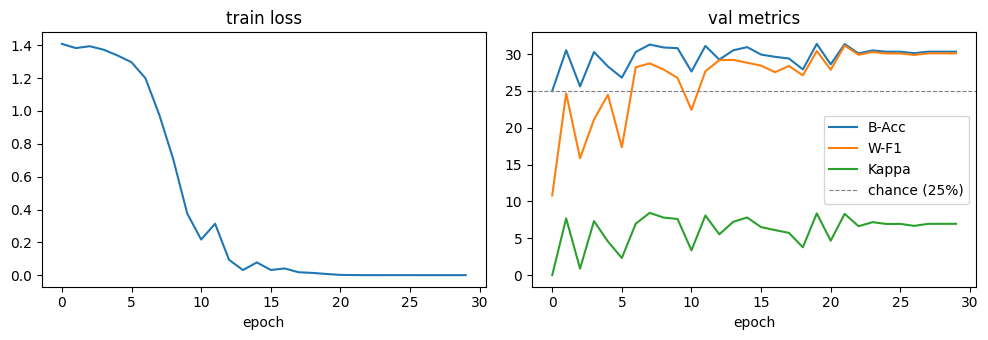

In [8]:
metrics_out = {
    'run_name': RUN_NAME,
    'checkpoint': str(CKPT_PATH.relative_to(REPO_ROOT)),
    'pretrain_epoch': int(ckpt['epoch']),
    'embed_dim': EMBED_DIM,
    'depth': DEPTH,
    'n_params_total': n_total,
    'n_params_trainable': n_train,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'lr_head': LR_HEAD,
    'lr_backbone': LR_BACKBONE,
    'weight_decay': WEIGHT_DECAY,
    'best_val_bacc': history.best_val_bacc,
    'best_epoch': history.best_epoch,
    'test_bacc':  test_metrics['bacc'],
    'test_wf1':   test_metrics['wf1'],
    'test_kappa': test_metrics['kappa'],
    'history': {
        'train_loss': history.train_loss,
        'val_bacc':   history.val_bacc,
        'val_wf1':    history.val_wf1,
        'val_kappa':  history.val_kappa,
    },
}
with open(OUT_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)
print('wrote', OUT_DIR / 'metrics.json')

torch.save(history.best_state_dict, OUT_DIR / 'best_model.pt')
print('wrote', OUT_DIR / 'best_model.pt')

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(history.train_loss); ax[0].set_title('train loss'); ax[0].set_xlabel('epoch')
ax[1].plot(np.array(history.val_bacc)*100, label='B-Acc')
ax[1].plot(np.array(history.val_wf1)*100,  label='W-F1')
ax[1].plot(np.array(history.val_kappa)*100, label='Kappa')
ax[1].axhline(25.0, color='gray', ls='--', lw=0.8, label='chance (25%)')
ax[1].set_title('val metrics'); ax[1].set_xlabel('epoch'); ax[1].legend()
fig.tight_layout()
fig.savefig(OUT_DIR / 'curves.png', dpi=120)
plt.show()

## 9. Comparison vs EEG-FM-Bench Table 2

In [9]:
baselines = {
    'EEGPT (best)': 44.07, 'CsBrain': 36.23, 'BENDR': 35.21,
    'CBraMod': 33.71, 'REVE': 32.73, 'LaBraM': 28.50, 'BIOT': 22.08,
}
ours = test_metrics['bacc'] * 100
print(f'{"Model":<22} {"B-Acc":>7}  Δ vs EEGPT')
print('-' * 42)
for name, score in baselines.items():
    print(f'{name:<22} {score:>6.2f}   {score - 44.07:+6.2f}')
print(f'{"OURS (" + RUN_NAME + ")":<22} {ours:>6.2f}   {ours - 44.07:+6.2f}')

Model                    B-Acc  Δ vs EEGPT
------------------------------------------
EEGPT (best)            44.07    +0.00
CsBrain                 36.23    -7.84
BENDR                   35.21    -8.86
CBraMod                 33.71   -10.36
REVE                    32.73   -11.34
LaBraM                  28.50   -15.57
BIOT                    22.08   -21.99
OURS (official)         31.10   -12.97
